In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

In [2]:
data = fetch_california_housing()
X = data.data[:,2].reshape(-1,1)
y = data.target
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
m = 0
b = 0
learning_rate  = 0.001
epochs = 1000
n = len(X_train)
for i in range(epochs):
    y_pred = m * X_train.flatten() + b
    dm = (-2/n) * np.sum(X_train.flatten() * (y_train - y_pred))
    db = (-2/n) * np.sum(y_train - y_pred)
    m = m - learning_rate * dm
    b = b - learning_rate * db
    y_pred_gd = m * X_test.flatten() + b
print("Gradient Descent")
print("Slope=",m)
print("Inteercept=",b)
print("MSE",mean_squared_error(y_test,y_pred_gd))
print("R2 Score=",r2_score(y_test,y_pred_gd))

Gradient Descent
Slope= 0.25797761849057654
Inteercept= 0.4850206129374197
MSE 1.6449229482854868
R2 Score= -0.2552744796465303


In [5]:
X_train_new = np.c_[np.ones((len(X_train),1)),X_train]
X_test_new = np .c_[np.ones((len(X_test),1)),X_test]
theta = np.linalg.inv(X_train_new.T.dot(X_train_new)).dot(X_train_new.T).dot(y_train)
y_pred_ne = X_test_new.dot(theta)
print("\nNormal Equation")
print("Intercept=",theta[0])
print("Slope=",theta[1])
print("MSE=",mean_squared_error(y_test,y_pred_ne))
print("R2 Score =",r2_score(y_test,y_pred_ne))


Normal Equation
Intercept= 1.6547622685968384
Slope= 0.07675558963126795
MSE= 1.2923314440807303
R2 Score = 0.013795337532284568


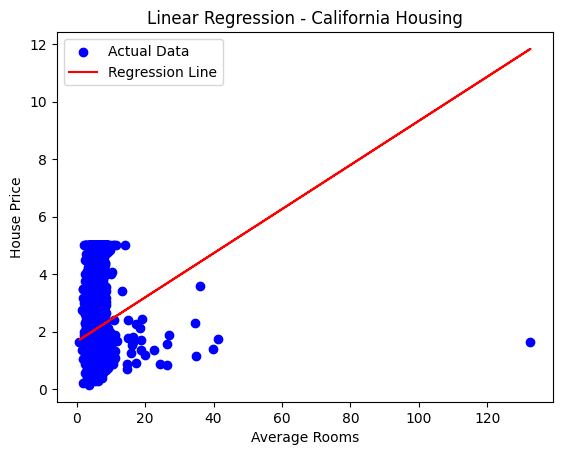

In [6]:
plt.scatter(X_test,y_test,color="blue",label="Actual Data")
plt.plot(X_test,y_pred_ne,color="red",label="Regression Line")
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Linear Regression - California Housing")
plt.legend()
plt.show()